In [1]:
# Import libs
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import os

# **I. DATA CLEANING**

In [ ]:
### Read in JSON files (Category names):

# ca_json = pd.read_json("./Kaggle_data/CA_category_id.json")["items"].to_dict()
# us_json = pd.read_json("./Kaggle_data/US_category_id.json")["items"].to_dict()
#       --------- OR ---------
url_ca_json = "https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Cap2_YouTube/2_DataWrangling/Kaggle_data/CA_category_id.json"
url_us_json = "https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Cap2_YouTube/2_DataWrangling/Kaggle_data/US_category_id.json"
ca_json = pd.read_json(url_ca_json)["items"].to_dict()
us_json = pd.read_json(url_us_json)["items"].to_dict()

cat_id  = []
cat_val = []
for idx in ca_json.values():
    cat_id.append( int(idx["id"]) )
    cat_val.append(idx["snippet"]["title"])
for idx in us_json.values():
    cat_id.append( int(idx["id"]) )
    cat_val.append(idx["snippet"]["title"])

category_mapping = pd.DataFrame({'category_id':cat_id, 'category':cat_val }).drop_duplicates()

In [ ]:
### Read in CSV files (Core data files):

# ca_csv = pd.read_csv("./Kaggle_data/CAvideos.csv")
# us_csv = pd.read_csv("./Kaggle_data/USvideos.csv")
#       --------- OR ---------
url_ca_csv = "https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Cap2_YouTube/2_DataWrangling/Kaggle_data/CAvideos.csv"
url_us_csv = "https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Cap2_YouTube/2_DataWrangling/Kaggle_data/USvideos.csv"
ca_csv = pd.read_csv(url_ca_csv)
us_csv = pd.read_csv(url_us_csv)

ca_csv['country'] = "Canada"
us_csv['country'] = "USA"

allCSV = pd.concat([ca_csv,us_csv], axis=0)
print("CSV dimensions: ", ca_csv.shape, " + ", us_csv.shape, " = ", allCSV.shape)


CSV dimensions:  (40881, 17)  +  (40949, 17)  =  (81830, 17)


In [ ]:
#Merge all data:
allData = pd.merge(allCSV, category_mapping, on="category_id", how="left")

print("Dimensions: ", allData.shape, "\n\n")
print(allData.columns.values,"\n")
print(allData.dtypes)

Dimensions:  (81830, 18) 


['video_id' 'trending_date' 'title' 'channel_title' 'category_id'
 'publish_time' 'tags' 'views' 'likes' 'dislikes' 'comment_count'
 'thumbnail_link' 'comments_disabled' 'ratings_disabled'
 'video_error_or_removed' 'description' 'country' 'category'] 

video_id                  object
trending_date             object
title                     object
channel_title             object
category_id                int64
publish_time              object
tags                      object
views                      int64
likes                      int64
dislikes                   int64
comment_count              int64
thumbnail_link            object
comments_disabled           bool
ratings_disabled            bool
video_error_or_removed      bool
description               object
country                   object
category                  object
dtype: object


In [ ]:
### Convert to correct type:

allData['trending_date'] = pd.to_datetime(allData['trending_date'], format="%y.%d.%m")

allData['publish_datetime']  = pd.to_datetime(allData['publish_time'], utc=True)
allData['publish_date']  = pd.to_datetime(allData['publish_datetime'].dt.date, format="%y.%d.%m")
print(allData.dtypes)

video_id                               object
trending_date                  datetime64[ns]
title                                  object
channel_title                          object
category_id                             int64
publish_time                           object
tags                                   object
views                                   int64
likes                                   int64
dislikes                                int64
comment_count                           int64
thumbnail_link                         object
comments_disabled                        bool
ratings_disabled                         bool
video_error_or_removed                   bool
description                            object
country                                object
category                               object
publish_datetime          datetime64[ns, UTC]
publish_date                   datetime64[ns]
dtype: object


In [ ]:
### Do we need 'video_error_or_removed' column?

## Deleted videos, based on title:
deleted_id = allData[allData.title=="Deleted video"]["video_id"].unique()

## Using flag 'video_error_or_removed':
err_rem_id = allData[allData.video_error_or_removed]["video_id"].unique()

## Videos uniquely flagged by 'video_error_or_removed':
uniq_err_id = list(set(err_rem_id) - set(deleted_id)) #['KjSSU1trCug','0JqXITEsMy8','q8v9MvManKE','BEePFpC9qG8','1Aoc-cd9eYs','RK_B4Ez4_5Q']
allData[allData.video_id.isin(uniq_err_id)].sort_values(["video_id","country","publish_datetime","trending_date"]).head()


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country,category,publish_datetime,publish_date
28720,0JqXITEsMy8,2018-04-15,Coachella 2018 LIVE Channel 1 (CA),Coachella,10,2018-04-05T06:56:09.000Z,[none],8478721,226862,5039,22284,https://i.ytimg.com/vi/0JqXITEsMy8/default_liv...,False,False,True,For more cameras tune in @ https://yt.be/coach...,Canada,Music,2018-04-05 06:56:09+00:00,2018-04-05
32758,1Aoc-cd9eYs,2018-05-05,Cobra Kai Ep 2 - Strike First - The Karate Kid...,Cobra Kai,24,2018-05-02T16:02:35.000Z,"Cobra Kai|""Karate Kid""|""YouTube Red Original S...",673534,27216,930,2630,https://i.ytimg.com/vi/1Aoc-cd9eYs/default.jpg,False,False,True,Present day Daniel LaRusso lives a charmed lif...,Canada,Entertainment,2018-05-02 16:02:35+00:00,2018-05-02
33019,1Aoc-cd9eYs,2018-05-06,Cobra Kai Ep 2 - Strike First - The Karate Kid...,Cobra Kai,24,2018-05-02T16:02:35.000Z,"Cobra Kai|""Karate Kid""|""YouTube Red Original S...",982049,23414,1313,4466,https://i.ytimg.com/vi/1Aoc-cd9eYs/default.jpg,False,False,True,Present day Daniel LaRusso lives a charmed lif...,Canada,Entertainment,2018-05-02 16:02:35+00:00,2018-05-02
73639,1Aoc-cd9eYs,2018-05-05,Cobra Kai Ep 2 - Strike First - The Karate Kid...,Cobra Kai,24,2018-05-02T16:02:35.000Z,"Cobra Kai|""Karate Kid""|""YouTube Red Original S...",833027,28696,3766,5033,https://i.ytimg.com/vi/1Aoc-cd9eYs/default.jpg,False,False,True,Present day Daniel LaRusso lives a charmed lif...,USA,Entertainment,2018-05-02 16:02:35+00:00,2018-05-02
73852,1Aoc-cd9eYs,2018-05-06,Cobra Kai Ep 2 - Strike First - The Karate Kid...,Cobra Kai,24,2018-05-02T16:02:35.000Z,"Cobra Kai|""Karate Kid""|""YouTube Red Original S...",641055,4800,177,1223,https://i.ytimg.com/vi/1Aoc-cd9eYs/default.jpg,False,False,True,Present day Daniel LaRusso lives a charmed lif...,USA,Entertainment,2018-05-02 16:02:35+00:00,2018-05-02


# **II. DATA WRANGLING**

In [ ]:
### Filter data for only required data (ID columns: video_id, country)

## Row-filters: latest publish_datetime, followed by earliest trending date.
filtered_idx = allData[allData.title!="Deleted video"].\
                sort_values(["video_id","country","publish_datetime","trending_date"]).\
                groupby(["video_id","country"])["publish_datetime"].\
                idxmax().values

## Col-filter: Not required for our analysis
drop_cols = ["thumbnail_link","video_error_or_removed"]

## Apply both filters
filtrData = allData.loc[allData.index.isin(filtered_idx), ~allData.columns.isin(drop_cols)]
print(filtrData.columns)

## Check for missing values:
print("\n",filtrData.isna().sum())

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'comments_disabled', 'ratings_disabled', 'description', 'country',
       'category', 'publish_datetime', 'publish_date'],
      dtype='object')

 video_id                0
trending_date           0
title                   0
channel_title           0
category_id             0
publish_time            0
tags                    0
views                   0
likes                   0
dislikes                0
comment_count           0
comments_disabled       0
ratings_disabled        0
description          1075
country                 0
category                0
publish_datetime        0
publish_date            0
dtype: int64


In [ ]:
## Description column is not a primary feature, thus fixing NaN is easy: fill with "".
filtrData["description"] = filtrData["description"].fillna("")

In [ ]:
# Reorder columns: ID vars, followed by features
id_cols = ["video_id","publish_datetime","trending_date","title","channel_title","category","category_id","country","description","publish_date","publish_time","views","likes","dislikes","comment_count"]
new_col_order = id_cols + filtrData.columns[ ~filtrData.columns.isin(id_cols)].tolist()
filtrData = filtrData[new_col_order]

filtrData.columns

Index(['video_id', 'publish_datetime', 'trending_date', 'title',
       'channel_title', 'category', 'category_id', 'country', 'description',
       'publish_date', 'publish_time', 'views', 'likes', 'dislikes',
       'comment_count', 'tags', 'comments_disabled', 'ratings_disabled'],
      dtype='object')

In [ ]:
### Deriving new features:

## No. of tags:
filtrData['n_tags'] = filtrData['tags'].apply(lambda x: len(x.split("|")) )

## No. of Repeats:
trend_rep_dt = allData.groupby(['video_id','country','publish_datetime']).\
                size().rename("trend_rep") - 1
filtrData = pd.merge(filtrData, trend_rep_dt, on=["video_id","country","publish_datetime"], how="left", validate="one_to_one")

## Trending category:
trendCat_conditions = [filtrData.trend_rep==0, filtrData.trend_rep>0]
trendCat_values = ["One-time hit", "Repeat hit"]
filtrData['trend_cat'] = np.select(trendCat_conditions, trendCat_values, default="")

# Age of video: Earliest trending date - Publish date
filtrData['age'] = (filtrData['trending_date'] - filtrData['publish_date']).dt.days.astype(int)

#Comments and Rating status (helpful when encoding values pre-modelling)
filtrData["comments_status"] = filtrData["comments_disabled"].astype("int")
filtrData["ratings_status"]  = filtrData["ratings_disabled"].astype("int")

filtrData.head(5)

,video_id,publish_datetime,trending_date,title,channel_title,category,category_id,country,description,publish_date,...,comment_count,tags,comments_disabled,ratings_disabled,n_tags,trend_rep,trend_cat,age,comments_status,ratings_status
0,n1WpP7iowLc,2017-11-10 17:00:03+00:00,2017-11-14,Eminem - Walk On Water (Audio) ft. Beyoncé,EminemVEVO,Music,10,Canada,Eminem's new track Walk on Water ft. Beyoncé i...,2017-11-10,...,125882,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",False,False,6,3,Repeat hit,4,0,0
1,0dBIkQ4Mz1M,2017-11-13 17:00:00+00:00,2017-11-14,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV,Comedy,23,Canada,STill got a lot of packages. Probably will las...,2017-11-13,...,13030,"plush|""bad unboxing""|""unboxing""|""fan mail""|""id...",False,False,11,4,Repeat hit,1,0,0
2,5qpjK5DgCt4,2017-11-12 19:05:24+00:00,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,Comedy,23,Canada,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,2017-11-12,...,8181,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",False,False,23,3,Repeat hit,2,0,0
3,d380meD0W0M,2017-11-12 18:01:41+00:00,2017-11-14,I Dare You: GOING BALD!?,nigahiga,Entertainment,24,Canada,I know it's been a while since we did this sho...,2017-11-12,...,17518,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",False,False,14,3,Repeat hit,2,0,0
4,2Vv-BfVoq4g,2017-11-09 11:04:14+00:00,2017-11-14,Ed Sheeran - Perfect (Official Music Video),Ed Sheeran,Music,10,Canada,🎧: https://ad.gt/yt-perfect\n💰: https://atlant...,2017-11-09,...,85067,"edsheeran|""ed sheeran""|""acoustic""|""live""|""cove...",False,False,10,1,Repeat hit,5,0,0


In [ ]:
# Check if the file exists and remove it
filename = 'clean_data.pkl'
if os.path.isfile(filename):
    os.remove(filename)
filtrData.to_pickle('clean_data.pkl')

# If running on Google colab:
from google.colab import files
files.download('./clean_data.pkl')

print(f"filtrData saved as 'clean_data.pkl'")

ModuleNotFoundError: No module named 'google.colab'

# **III. DATA EXPLORATION**

In [ ]:
# Read processed clean data (from GitHub):
filename = 'clean_data.pkl'
if os.path.isfile(filename):
    os.remove(filename)

!wget https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Capstone_2/2_DataWrangling/clean_data.pkl
filtrData = pd.read_pickle("clean_data.pkl")

In [ ]:
## Histogram of trend_rep
sns.histplot(filtrData.trend_rep[filtrData['trend_rep']>0], bins=30)

plt.xlabel('Occurance count')
plt.ylabel('Frequency')

plt.xticks(ticks=range(1, max(filtrData['trend_rep'])+1, 2))
plt.title('Histogram of \n Occurances in Trending List')
plt.show()

In [ ]:
## Histogram of Age
x = filtrData.groupby('age')['age'].count().rename("n").reset_index().sort_values(['n','age'], ascending=False)
sns.barplot(data=x[x['age']>1], x='age', y='n')

plt.xlabel('Age of video')
plt.ylabel('Frequency')

# plt.xticks(ticks=range(1, max(filtrData['age'])+1, 2))
plt.title('Histogram of Age')
plt.show()
x.loc[x.n==1,'age'].min()

Trending repeats could be further subclassified into following classes if furtehr aalysis is required:
*   Common repeats (1-2)
*   Rare repeats (3-7)
*   Epic repeats (8-15)
*   Legendary repeats (>15)
---



### Testing for outliers
Numeric matrix is plotted against a general series. Red dotted line in plots indicates the 95% percentile mark

In [ ]:
numeric_metrics = ["views","likes","dislikes","comment_count","n_tags","age","trend_rep"]
dt = filtrData.loc[:, numeric_metrics+['trend_cat']]

plt.clf()
title_names = numeric_metrics[0:3] + ["Comment count","Number of tags","Age","Number of trending repeats"]
label_names = [i+" (in millions)" for i in numeric_metrics[0:4]] + ["age","n_tags","trend_rep"]

for i in range(6):
  num_var = dt.iloc[:, i]/1e6 if i<4 else dt.iloc[:, i]
  percentile_line = int(np.percentile(num_var, 95))

  plt.figure(figsize=(6, 6))
  sns.scatterplot( x=range(len(num_var+1)), y=num_var, hue=filtrData['trend_cat'])
  plt.axhline(y=percentile_line, color='red', linestyle='--', linewidth=2)  # Adjust color, style, and thickness as needed
  plt.ylabel(label_names[i])
  plt.title(title_names[i])
  plt.show()


In [ ]:
## Counts per trending occurance (category)
filtrData.groupby("trend_cat")["trend_cat"].count().\
  rename("n").reset_index()

### Correlation plot

In [ ]:
## Create a heatmap

heat_dt = filtrData.loc[:, ["views","likes","dislikes","comment_count","n_tags","trend_rep"]].corr()
sns.heatmap(heat_dt, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
plt.clf()
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 10))

for i in range(3):
  for j in range(2):
    n = 2*i + j

    sns.boxplot(ax=axes[i][j], y=filtrData[numeric_metrics[n]], hue=filtrData["trend_cat"])
    axes[i][j].set_title('Box Plot for ' + numeric_metrics[n])
    axes[i][j].set_yscale("log")

plt.show()


In [ ]:
# Closer look at Age metric (central):
median_age_repeathit = np.median(filtrData.loc[filtrData["trend_cat"]=="One-time hit", "age"])
median_age_onehit    = np.median(filtrData.loc[filtrData["trend_cat"]=="Repeat hit", "age"])

print("Median of Age:\n")
print(f'Repeat hits = {median_age_repeathit:.5f}')
print(f'One-time hits = {median_age_onehit:.5f}')

A quick look at how our numeric metrics compare for both categories helps acertain that **view, likes, dislikes, and comment count** likely plays a significant factor.

**Number of tags** appeared to be surprisingly similar for both groups. Also, even though the box plots for **Age** seeemed different their median are almost identical, making this a likely inefective contributing factor.

In [ ]:

sns.histplot(filtrData['views'], bins=100); plt.show()
sns.histplot(filtrData['likes'], bins=100); plt.show()
sns.histplot(filtrData['dislikes'], bins=100); plt.show()
sns.histplot(filtrData['comment_count'], bins=100)

plt.show()

Our data is far from following a Gaussian distribtion & seems to have a lot of extreme outliers. But that doesnt mean these data points can be discredited.

# IV. MODELLING

In [2]:
# Pre-modelling
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# Classifier Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Save model as file
from joblib import dump, load
import time

# Performance test
from sklearn.metrics import mean_squared_error, confusion_matrix, ConfusionMatrixDisplay, classification_report

Libraries imported for Modelling exclusively

### Pre-processing data

In [3]:
# Check if the file exists and remove it
filename = 'clean_data.pkl'

# # ONLY IF using Google colab
if os.path.isfile(filename):
    os.remove(filename)
!wget https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Cap2_YouTube/2_DataWrangling/clean_data.pkl
filtrData = pd.read_pickle('clean_data.pkl')
filtrData.dtypes

--2025-04-30 15:45:04--  https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Cap2_YouTube/2_DataWrangling/clean_data.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45216255 (43M) [application/octet-stream]
Saving to: ‘clean_data.pkl’

clean_data.pkl      100%[===================>]  43.12M   146MB/s    in 0.3s    

2025-04-30 15:45:05 (146 MB/s) - ‘clean_data.pkl’ saved [45216255/45216255]



,0
video_id,object
publish_datetime,"datetime64[ns, UTC]"
trending_date,datetime64[ns]
title,object
channel_title,object
category,object
category_id,int64
country,object
description,object
publish_date,datetime64[ns]


In [ ]:
retain_vars = ['trend_cat', #Prediced/Dependent var
               'views', 'likes', 'dislikes', 'age', 'n_tags', 'comment_count', #Numeric features
               'category', 'comments_status', 'ratings_status', #Categorical features
              ]
modelData = filtrData[retain_vars]
modelData = pd.get_dummies(modelData, columns=["category"], drop_first=True, dtype="int")
modelData["trend_cat_coded"] = [1 if i=="Repeat hit" else 0 for i in modelData["trend_cat"]]
modelData.drop("trend_cat", axis=1, inplace=True)

print(modelData.shape)
modelData.head()

(30769, 25)


,views,likes,dislikes,age,n_tags,comment_count,comments_status,ratings_status,category_Comedy,category_Education,...,category_Music,category_News & Politics,category_Nonprofits & Activism,category_People & Blogs,category_Pets & Animals,category_Science & Technology,category_Shows,category_Sports,category_Travel & Events,trend_cat_coded
0,17158579,787425,43420,4,6,125882,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,1014651,127794,1688,1,11,13030,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
2,3191434,146035,5339,2,23,8181,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
3,2095828,132239,1989,2,14,17518,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,33523622,1634130,21082,5,10,85067,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1


In [ ]:
# Scaling data (only numeric features):
scaler = StandardScaler()
scaledData = pd.DataFrame(scaler.fit_transform(modelData.iloc[:, :6]),
                          columns=modelData.columns[:6])

#Apply scaledData back to modelData
for i, col in enumerate(modelData.columns.values[:6]):
  modelData[col] = scaledData.iloc[:, i]

modelData.head()

,views,likes,dislikes,age,n_tags,comment_count,comments_status,ratings_status,category_Comedy,category_Education,...,category_Music,category_News & Politics,category_Nonprofits & Activism,category_People & Blogs,category_Pets & Animals,category_Science & Technology,category_Shows,category_Sports,category_Travel & Events,trend_cat_coded
0,12.504293,9.912764,6.171796,-0.027092,-1.065304,9.170144,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,0.355426,1.373176,0.116575,-0.054831,-0.671939,0.749199,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
2,1.993531,1.609325,0.646328,-0.045585,0.272138,0.387370,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
3,1.169049,1.430721,0.160250,-0.045585,-0.435920,1.084091,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,24.819557,20.874213,2.930602,-0.017845,-0.750612,6.124555,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1


In [ ]:
print(modelData.dtypes)

views                             float64
likes                             float64
dislikes                          float64
age                               float64
n_tags                            float64
comment_count                     float64
comments_status                     int32
ratings_status                      int32
category_Comedy                     int32
category_Education                  int32
category_Entertainment              int32
category_Film & Animation           int32
category_Gaming                     int32
category_Howto & Style              int32
category_Movies                     int32
category_Music                      int32
category_News & Politics            int32
category_Nonprofits & Activism      int32
category_People & Blogs             int32
category_Pets & Animals             int32
category_Science & Technology       int32
category_Shows                      int32
category_Sports                     int32
category_Travel & Events          

In [ ]:
X = modelData.drop("trend_cat_coded", axis=1)
y = modelData['trend_cat_coded']
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y,train_size = 0.80, random_state = 97)
                                                # , stratify = y)

print(Xtrain.shape, ytrain.shape)
print(Xtest.shape, ytest.shape)

(24615, 24) (24615,)
(6154, 24) (6154,)


## 1. Logistic Regression

### 1.1. Fitting the model

In [ ]:
lr = LogisticRegression()
lr.fit(Xtrain, ytrain)

# lr.predict(Xtest)
lr.score(Xtest, ytest)

0.6322716932076698

### 1.2. Hyperparameter testing

In [ ]:
lr_params = {'max_iter' : [50, 100, 300, 500],
             'C' : [0.01, 0.1, 1, 10, 100]
            }
gridsearch_lr = GridSearchCV(lr, lr_params, cv=5)
gridsearch_lr.fit(Xtrain, ytrain)

lr_bestParams = gridsearch_lr.best_params_
lr_bestScore = gridsearch_lr.best_score_
lr_bestEstimator = gridsearch_lr.best_estimator_

print("Best parameters = ",lr_bestParams)
print("Best score = ", round(lr_bestScore,3))

Best parameters =  {'C': 10, 'max_iter': 50}
Best score =  0.629


### 1.3. Save best model to ext. file:

(1) Exporting model:

In [ ]:
# Check if the file exists and remove it
filename = './models/best_LogisticReg.joblib'
if os.path.isfile(filename):
    os.remove(filename)
dump(lr_bestEstimator, filename)

# # ONLY IF running on Google colab:
# from google.colab import files
# files.download(filename)

print(f"Logistic Regression model saved as 'best_LogisticReg.joblib'")

Logistic Regression model saved as 'best_LogisticReg.joblib'


(2) Importing model (from GitHub/locally)

In [ ]:
# Check if the file exists and remove it
filename = './models/best_LogisticReg.joblib'

# # ONLY IF running on Google colab:
# if os.path.isfile(filename):
#     os.remove(filename)
# if not os.path.isdir('models'):
#     !mkdir models;
# !wget -P ./models https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Cap2_YouTube/2_DataWrangling/models/best_LogisticReg.joblib
lr_bestEstimator = load(filename)

### Evaluate model:

In [ ]:
# classification report:
y_pred_lr = lr_bestEstimator.predict(Xtest)

from sklearn.metrics import classification_report
print(classification_report(ytest, y_pred_lr))

              precision    recall  f1-score   support

           0       0.61      0.73      0.66      3047
           1       0.67      0.54      0.60      3107

    accuracy                           0.63      6154
   macro avg       0.64      0.63      0.63      6154
weighted avg       0.64      0.63      0.63      6154



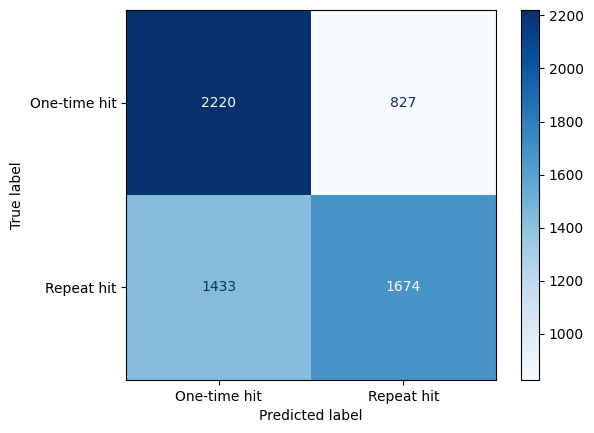

In [ ]:
# Confusion matrix:
cm_lr = confusion_matrix(ytest, lr_bestEstimator.predict(Xtest))

# Display CM as a heatmap:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['One-time hit', 'Repeat hit'])
disp.plot(cmap='Blues')
plt.show()

## 2. SVM model:

### 2.1. Fitting model

In [ ]:
t1 = datetime.now().strftime("%H:%M:%S")

svm = SVR()
svm.fit(Xtrain, ytrain)

# Evaluate the model
y_pred_svm = svm.predict(Xtest)
print(f"Score: {round(svm.score(Xtest, ytest),3)}")
print(f"RMSE: {round(np.sqrt(mean_squared_error(ytest, y_pred_svm)),3)}")

#Print runtime
t2 = datetime.now().strftime("%H:%M:%S")
print( f"Runtime = {datetime.strptime(t2, '%H:%M:%S') - datetime.strptime(t1, '%H:%M:%S')}" )


Score: -0.019
RMSE: 0.505
Runtime = 0:00:32


### 2.2. Hyperparameter testing:

In [ ]:
t1 = datetime.now().strftime("%H:%M:%S")

svm_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf']
    # 'gamma': [0.001, 0.01, 0.1, 1]
    # 'degree': [2, 3, 4],  # Only for 'poly' kernel
    # 'coef0': [0.0, 0.5, 1.0],  # Only for 'poly' and 'sigmoid' kernels
}
gridsearch_svm = GridSearchCV(svm, svm_params, cv=3, n_jobs=2)
                              # , random_state=97)
gridsearch_svm.fit(Xtrain, ytrain)

svm_bestParams = gridsearch_svm.best_params_
svm_bestScore  = gridsearch_svm.best_score_
svm_bestEstimator = gridsearch_svm.best_estimator_

print("Best parameters = ",svm_bestParams)
print("Best score = ", round(svm_bestScore,3))

#Print runtime
t2 = datetime.now().strftime("%H:%M:%S")
print( f"Runtime = {datetime.strptime(t2, '%H:%M:%S') - datetime.strptime(t1, '%H:%M:%S')}" )

Best parameters =  {'C': 0.01, 'kernel': 'rbf'}
Best score =  -0.019
Runtime = 0:06:44


### 2.3. Save best model to ext. file:

(1) Exporting model:

In [ ]:
# Check if the file exists and remove it
filename = './models/best_SVM.joblib'
if os.path.isfile(filename):
    os.remove(filename)
dump(svm_bestEstimator, filename)

# # ONLY if running on Google colab:
# from google.colab import files
# files.download('./best_SVM.joblib')

print(f"SVM model saved as \n'{os.getcwd()}/best_SVM.joblib'")

SVM model saved as 
'E:\Springboard_Workplace\GitHub repos\Springboard_RT\Capstone_2\2_DataWrangling/best_SVM.joblib'


(2) Import model (from GitHub/locally)

In [23]:
# Check if the file exists and remove it
filename = './models/best_SVM.joblib'

# # ONLY if running on Google colab:
# if os.path.isfile(filename):
#     os.remove(filename)
# if not os.path.isdir('models'):
#     !mkdir models;
# !wget -P ./models https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Cap2_YouTube/2_DataWrangling/models/best_SVM.joblib
svm_bestEstimator = load(filename)

--2025-04-30 15:56:05--  https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Cap2_YouTube/2_DataWrangling/models/best_SVM.joblib
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4507884 (4.3M) [application/octet-stream]
Saving to: ‘./models/best_SVM.joblib’

best_SVM.joblib     100%[===================>]   4.30M  --.-KB/s    in 0.08s   

2025-04-30 15:56:06 (55.6 MB/s) - ‘./models/best_SVM.joblib’ saved [4507884/4507884]



/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SVR from version 1.4.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


### Evaluate model:

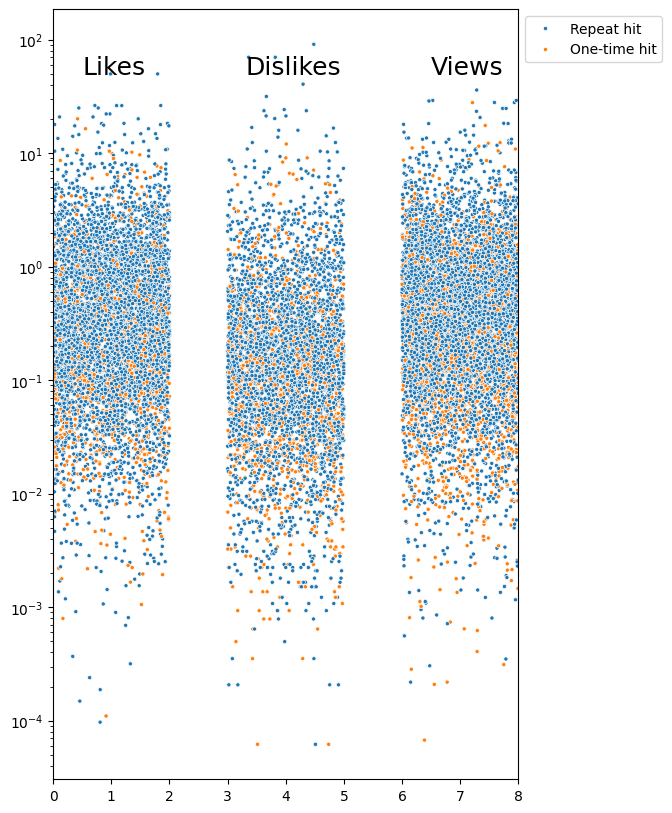

In [ ]:
x = [i for i in [1,4,7] for j in range(modelData.shape[0]) ] + np.random.uniform(-1, 1, size=modelData.shape[0]*3)

y = list(modelData['likes'].values) + list(modelData['dislikes'].values) + list(modelData['views'].values)

category = ["Repeat hit" if i==1 else "One-time hit" for i in list(modelData['trend_cat_coded'].values)*3]

plt.figure(figsize=(6, 10))
sns.scatterplot(x=x, y=y, hue=category, marker='.')

plt.text(0.5, 50, 'Likes', fontsize=18, color='black')
plt.text(3.3, 50, 'Dislikes', fontsize=18, color='black')
plt.text(6.5, 50, 'Views', fontsize=18, color='black')

plt.yscale('log')
plt.xlim(0,8)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()


SVM is discarded as a potential solution due to the following reasons:
*   This problem cannot be solved with a linear solution since the 2 categorical data are highly interspersed (i.e. non-linear data).
*   'rbf' is unable to generate a binary prediction
*   'poly' cannot handle such large amounts of data



In [ ]:
# y_pred_svm = svm_bestEstimator.predict(Xtest)
# print(classification_report(ytest, y_pred_svm))

In [ ]:
# # Confusion matrix:
# cm_svm = confusion_matrix(ytest, y_pred_svm)

# # Display CM as a heatmap:
# disp = ConfusionMatrixDisplay(confusion_matrix = cm_svm, display_labels = ['One-time hit', 'Repeat hit'])
# disp.plot(cmap='Blues')
# plt.show()

## 3. Random Forest

### 3.1. Fit the model

In [ ]:
rf = RandomForestClassifier(random_state=97)

# Fit the model
rf.fit(Xtrain, ytrain)
print(f"Random Forest Score: {round(rf.score(Xtest, ytest), 3)}")

Random Forest Score: 0.682


### 3.2. Hyperparameter Testing

In [ ]:
t1 = datetime.now().strftime("%H:%M:%S")

# Hyperparameter tuning for Random Forest
rf_params = {
    'n_estimators': [500 750, 850],
    'max_depth': [20, 35, 40, 45, 50],
    'min_samples_split': [5, 10, 15, 17, 20],
    'min_samples_leaf': [1, 2, 5]
}
gridsearch_rf = GridSearchCV(rf, rf_params, cv=5)
                             # , random_state=97)
gridsearch_rf.fit(Xtrain, ytrain)

rf_bestParams = gridsearch_rf.best_params_
rf_bestScore = gridsearch_rf.best_score_
rf_bestEstimator = gridsearch_rf.best_estimator_

print("Best parameters: ", rf_bestParams)
print("Best score: ", rf_bestScore)

#Print runtime
t2 = datetime.now().strftime("%H:%M:%S")
print( f"Runtime = {datetime.strptime(t2, '%H:%M:%S') - datetime.strptime(t1, '%H:%M:%S')}" )

Best parameters:  {'max_depth': 40, 'min_samples_leaf': 2, 'min_samples_split': 20, 'n_estimators': 850}
Best score:  0.6866138533414585
Runtime = 0:22:26


### 3.3. Save best model to ext. file:

In [ ]:
# Check if the file exists and remove it
filename = './models/best_RandForest.joblib'
if os.path.isfile(filename):
    os.remove(filename)
dump(rf_bestEstimator, filename)

# # If running on Google colab:
# from google.colab import files
# files.download('./best_RandForest.joblib')

print(f"Random Forest model saved as '{filename}'")

Random Forest model saved as './models/best_RandForest.joblib'


In [22]:
# Check if the file exists and remove it
filename = './models/best_RandForest.joblib'

# # ONLY IF running on Google colab:
# if os.path.isfile(filename):
#     os.remove(filename)
# if not os.path.isdir('models'):
#     !mkdir models;
# !wget -P ./models https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Cap2_YouTube/2_DataWrangling/models/best_RandForest.joblib
rf_bestEstimator = load(filename)

Pass
--2025-04-30 15:53:34--  https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Cap2_YouTube/2_DataWrangling/models/best_RandForest.joblib
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 100864265 (96M) [application/octet-stream]
Saving to: ‘./models/best_RandForest.joblib’

best_RandForest.job 100%[===================>]  96.19M   273MB/s    in 0.4s    

2025-04-30 15:53:34 (273 MB/s) - ‘./models/best_RandForest.joblib’ saved [100864265/100864265]



/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.4.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.4.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


### 3.4. Evaluate model

              precision    recall  f1-score   support

           0       0.68      0.69      0.69      3047
           1       0.69      0.69      0.69      3107

    accuracy                           0.69      6154
   macro avg       0.69      0.69      0.69      6154
weighted avg       0.69      0.69      0.69      6154



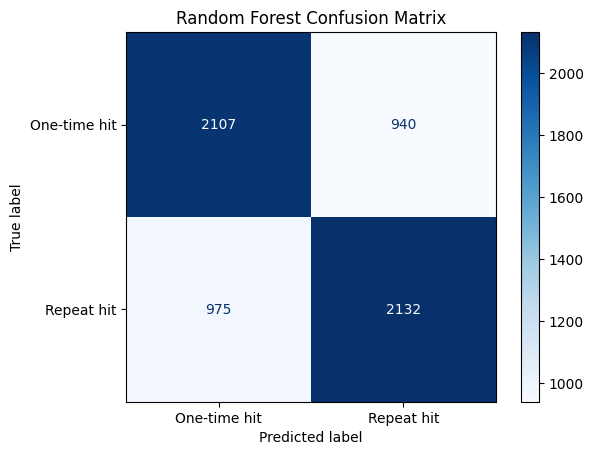

In [ ]:
y_pred_rf = rf_bestEstimator.predict(Xtest)
print(classification_report(ytest, y_pred_rf))

# Confusion matrix for Random Forest
cm_rf = confusion_matrix(ytest, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['One-time hit', 'Repeat hit'])
disp_rf.plot(cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()


## 4. Gradiant Boosting

### 4.1 Fit the model

In [ ]:
gb = GradientBoostingClassifier(random_state=97)

# Fit the model
gb.fit(Xtrain, ytrain)
print(f"Random Forest Score: {round(gb.score(Xtest, ytest), 3)}")

Random Forest Score: 0.671


### 4.2 Hyperparameter testing

In [ ]:
t1 = datetime.now().strftime("%H:%M:%S")

# Hyperparameter tuning for Random Forest
gb_params = {
    'n_estimators': [50, 100, 200, 500],       # Number of boosting stages
    'learning_rate': [0.01, 0.05, 0.1, 0.15],  # Shrinks contribution of each tree
    'max_depth': [3, 4, 5, 6, 7],              # Limits depth of individual trees
    'min_samples_split': [2, 4, 5, 7, 10],     # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4]              # Minimum samples in a leaf node
}
gridsearch_gb = GridSearchCV(gb, gb_params, cv=3,  n_jobs=4)
                             # , random_state=97)
gridsearch_gb.fit(Xtrain, ytrain)

gb_bestParams = gridsearch_gb.best_params_
gb_bestScore = gridsearch_gb.best_score_
gb_bestEstimator = gridsearch_gb.best_estimator_

print("Best parameters: ", gb_bestParams)
print("Best score: ", gb_bestScore)

#Print runtime
t2 = datetime.now().strftime("%H:%M:%S")
print( f"Runtime = {datetime.strptime(t2, '%H:%M:%S') - datetime.strptime(t1, '%H:%M:%S')}" )

Best parameters:  {'learning_rate': 0.05, 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 7, 'n_estimators': 200}
Best score:  0.6747511679869999
Runtime = 1:43:00


### 4.3 Save model to ext. file

(1) Exporting:

In [ ]:
# Check if the file exists and remove it
filename = './models/best_GradiantBoost.joblib'
if os.path.isfile(filename):
    os.remove(filename)
dump(gb_bestEstimator, './models/best_GradiantBoost.joblib')

# If running on Google colab:
# from google.colab import files
# files.download('./best_GradiantBoost.joblib')

print("Gradiant Boost model saved as:\n 'best_GradiantBoost.joblib'")

Gradiant Boost model saved as:
 'best_GradiantBoost.joblib'


(2) Import (from GitHub/locally):

In [11]:
# Check if the file exists and remove it
filename = './models/best_GradiantBoost.joblib'

# # ONLY IF running on Google colab:
# if os.path.isfile(filename):
#     os.remove(filename)
# if not os.path.isdir('models'):
#     !mkdir models;
# !wget -P ./models https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Cap2_YouTube/2_DataWrangling/models/best_GradiantBoost.joblib

gb_bestEstimator = load("./models/best_GradiantBoost.joblib")

total 46932
-rw-r--r-- 1 root root  2829852 Apr 30 15:47 best_GradiantBoost.joblib
-rw-r--r-- 1 root root 45216255 Apr 30 15:45 clean_data.pkl
drwxr-xr-x 2 root root     4096 Apr 30 15:46 models
drwxr-xr-x 1 root root     4096 Apr 28 13:28 sample_data
/content
--2025-04-30 15:47:46--  https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Cap2_YouTube/2_DataWrangling/models/best_GradiantBoost.joblib
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2829852 (2.7M) [application/octet-stream]
Saving to: ‘best_GradiantBoost.joblib.1’

best_GradiantBoost. 100%[===================>]   2.70M  --.-KB/s    in 0.07s   

2025-04-30 15:47:46 (36.1 MB/s) - ‘best_GradiantBoost.joblib.1’ saved [2829852/2829852]



AttributeError: Can't get attribute '__pyx_unpickle_CyHalfBinomialLoss' on <module 'sklearn._loss._loss' from '/usr/local/lib/python3.11/dist-packages/sklearn/_loss/_loss.cpython-311-x86_64-linux-gnu.so'>

### 4.4 Evaluate model

In [ ]:
y_pred_gb = gb_bestEstimator.predict(Xtest)
print(classification_report(ytest, y_pred_gb))

              precision    recall  f1-score   support

           0       0.67      0.68      0.68      3047
           1       0.69      0.67      0.68      3107

    accuracy                           0.68      6154
   macro avg       0.68      0.68      0.68      6154
weighted avg       0.68      0.68      0.68      6154



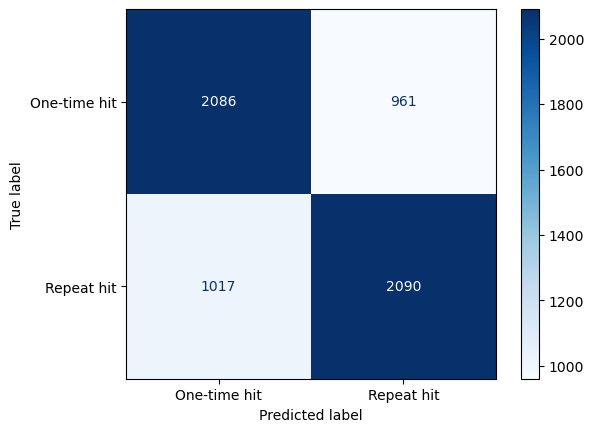

In [ ]:
# Confusion matrix:
cm_gb = confusion_matrix(ytest, y_pred_gb)

# Display CM as a heatmap:
disp = ConfusionMatrixDisplay(confusion_matrix = cm_gb, display_labels = ['One-time hit', 'Repeat hit'])
disp.plot(cmap='Blues')
plt.show()

In [ ]:
rf_predictions = gb_bestEstimator.predict_proba(Xtrain)

NameError: name 'gb_bestEstimator' is not defined

In [ ]:

# Step 2: Train XGBoost (Boosting)
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(rf_predictions.reshape(-1, 1), y_train)